# Customer Churn Behaviour Analysis

## Objective
Analyse customer churn behaviour to identify patterns that drive churn and generate business recommendations to improve retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.shape

(7032, 21)

## 1. What is the overall customer churn rate?

Understanding the overall churn rate helps quantify how many customers are leaving the business and whether retention is a significant issue.

In [19]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### Insight

Approximately 26.6% of customers have churned, meaning roughly 1 in 4 customers leave the business.

This indicates a significant retention issue, suggesting the company should prioritise strategies to reduce churn and improve customer loyalty.

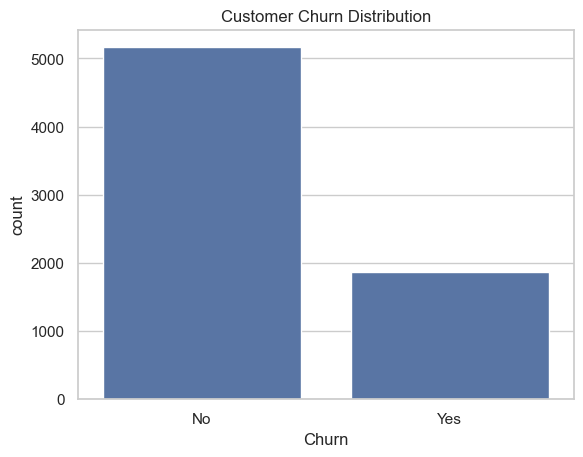

In [21]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

## 2. Does contract type influence customer churn?

Understanding how contract type impacts churn can help identify whether longer-term commitments improve customer retention.

<Axes: xlabel='Contract', ylabel='count'>

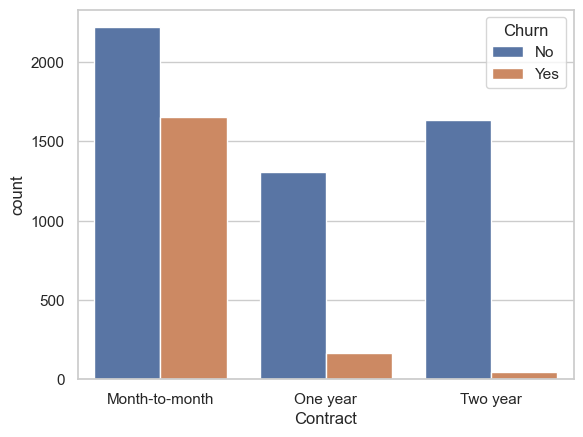

In [22]:
sns.countplot(x="Contract", hue="Churn", data=df)

### Insight

Customers on month-to-month contracts exhibit significantly higher churn compared to those on one-year and two-year contracts.

Churn decreases as contract length increases, suggesting that longer-term contracts are associated with stronger customer retention.

This indicates that the business could reduce churn by encouraging customers to move onto longer-term contracts.

There is a clear negative relationship betwen contract and length of churn

## 3. Does internet service type influence churn?

Analysing churn by internet service type helps identify whether certain products or services are linked to higher customer attrition.

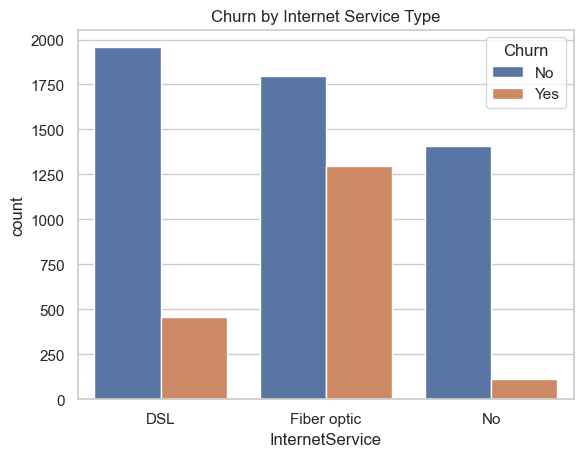

In [23]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service Type")
plt.show()

### Insight

Customers using fiber optic internet show the highest churn compared with DSL and customers with no internet service.

This suggests that fiber optic customers may be experiencing pricing, service quality, or expectation issues, and should be investigated further as a high-risk retention segment.

## 4. Do higher monthly charges lead to increased churn?

Understanding the relationship between pricing and churn can help identify whether cost is a key driver of customer attrition.

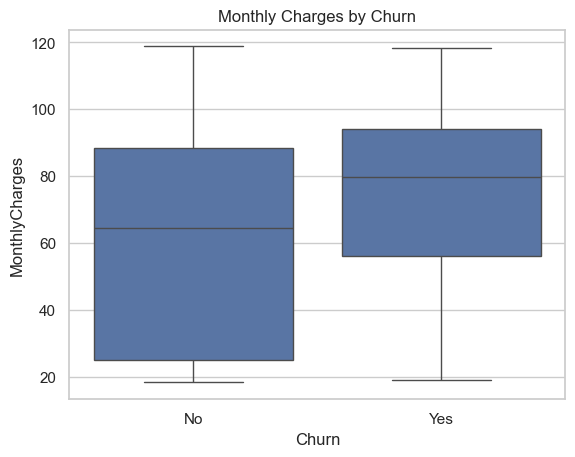

In [24]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

### Insight

Customers who churn tend to have higher monthly charges compared to those who stay.

This suggests that pricing may be a contributing factor to churn, and that higher-paying customers could be more sensitive to perceived value or cost.

The business may benefit from reviewing pricing strategies or improving value propositions for higher-paying customers.

## Final Insights

Analysis of customer churn reveals several key patterns:

- Customers on **month-to-month contracts** have significantly higher churn compared to longer-term contracts.
- **Fiber optic customers** show higher churn levels than DSL users.
- Customers with **higher monthly charges** are more likely to churn.

These findings suggest that churn is highest among customers who have low commitment and are paying higher costs.

## Business Recommendations

Based on the analysis, the following actions are recommended:

- Encourage customers to move from month-to-month to longer-term contracts through incentives or discounts.
- Investigate customer satisfaction and pricing for fiber optic services to identify potential issues.
- Review pricing strategies for higher-paying customers to ensure perceived value matches cost.
- Develop targeted retention strategies for high-risk customer segments.